### Authors

- Anna Beketova
- Shatu Ahmed

Target repository: [week7](https://gitlab.rlp.net/aibi_practical/aibi-ws-2024-25/-/tree/Embedding/week7)

# Labbook Week 7 - Embedding using Convolutional Layers with Sigmoid activation function and SGD optimizer

## Code

The dataset used during this week stems from the updated training set in the main branch, according to the provided [instructions](https://gitlab.rlp.net/a.hallab/aibi-ws-2024-25/-/blob/main/README.md?ref_type=heads)

### Data Preprocessing

In [15]:
import pandas as pd
from Bio import SeqIO
import csv

#read data
data = pd.read_csv("mapman_filtered.tsv", sep="\t")

# The dataset has already the form BINCODE - ID

bincode_dict = {} # dictionary to store all identifiers of each family


for index, row in data.iterrows():
    bincode = row['BINCODE'].strip("'")
    protein_id = row['IDENTIFIER'].strip("'").lower()
    if(protein_id):
        if(bincode not in bincode_dict):
            bincode_dict[bincode] = []
        bincode_dict[bincode].append(protein_id)


print(sum(len(v) for v in bincode_dict.values()))

print(bincode_dict[:2])


proteins = "protein_filtered.fa"
protein_dict = {}

for record in SeqIO.parse(proteins, "fasta"):
    uniprot_id = record.id.split("|")[-1].lower()
    sequence = str(record.seq)
    protein_dict[uniprot_id] = sequence

grouped_dict = {}
for bincode, protein_ids in bincode_dict.items():
    sequences = [protein_dict[p] for p in protein_ids if p in protein_dict]
    if sequences:
        grouped_dict[bincode] = sequences
    else:
        grouped_dict[bincode] = []

result = "labeled_sequences_newdataset.csv"
with open(result, "w") as newfile:
    newfile.write("bincode,sequence\n")
    for bincode, sequences in grouped_dict.items():
        for seq in sequences:
            newfile.write(f"{bincode}, {seq}\n")


cleaned_rows = []

with open("labeled_sequences_newdataset.csv", "r") as infile:
    reader = csv.reader(infile)
    for row in reader:
        if len(row) > 2:
            bincode = row[0]
            sequence = ''.join(row[1:]).replace('"', '').replace("'", "") # Merge falsely added columns and clean quotes
            cleaned_rows.append([bincode, sequence])
        elif len(row) == 2:
            cleaned_rows.append(row)
        else:
            print(f"Skipping malformed row: {row}")


with open("NEW_labeled_sequences.csv", "w") as outfile:
    writer = csv.writer(outfile)
    writer.writerows(cleaned_rows)

print("done")

ModuleNotFoundError: No module named 'Bio'

### Statistics for protein sequence lengths

In [6]:
import pandas as pd
import numpy as np

sequence_stat = pd.read_csv('NEW_labeled_sequences.csv')  

sequence_stat['sequence_length'] = sequence_stat['sequence'].apply(len)

average_length = sequence_stat['sequence_length'].mean()
median_length = sequence_stat['sequence_length'].median()
max_length = sequence_stat['sequence_length'].max()
min_length = sequence_stat['sequence_length'].min()

print("Statistics for protein sequence lengths:")
print(f"Average Length: {average_length}")
print(f"Median Length: {median_length}")
print(f"Maximum Length: {max_length}")
print(f"Minimum Length: {min_length}")


Statistics for protein sequence lengths:
Average Length: 479.29457595156566
Median Length: 447.0
Maximum Length: 4904
Minimum Length: 72


### Embedding using 10 Kidera factors


Embedding -> Truncating and Padding

In [18]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences

labled = pd.read_csv("NEW_labeled_sequences.csv")

# Kidera factors (without processing of not-aminoacid characters)
kidera_factors = {
    'A': [-1.56, -1.67, -0.97, -0.27, -0.93, -0.78, -0.2, -0.08, 0.21, -0.48],
    'C': [0.12, -0.89, 0.45, -1.05, -0.71, 2.41, 1.52, -0.69, 1.13, 1.1],
    'D': [0.58, -0.22, -1.58, 0.81, -0.92, 0.15, -1.52, 0.47, 0.76, 0.7],
    'E': [-1.45, 0.19, -1.61, 1.17, -1.31, 0.4, 0.04, 0.38, -0.35, -0.12],
    'F': [-0.21, 0.98, -0.36, -1.43, 0.22, -0.81, 0.67, 1.1, 1.71, -0.44],
    'G': [1.46, -1.96, -0.23, -0.16, 0.1, -0.11, 1.32, 2.36, -1.66, 0.46],
    'H': [-0.41, 0.52, -0.28, 0.28, 1.61, 1.01, -1.85, 0.47, 1.13, 1.63],
    'I': [-0.73, -0.16, 1.79, -0.77, -0.54, 0.03, -0.83, 0.51, 0.66, -1.78],
    'K': [-0.34, 0.82, -0.23, 1.7, 1.54, -1.62, 1.15, -0.08, -0.48, 0.6],
    'L': [-1.04, 0, -0.24, -1.1, -0.55, -2.05, 0.96, -0.76, 0.45, 0.93],
    'M': [-1.4, 0.18, -0.42, -0.73, 2, 1.52, 0.26, 1.23, -1.27, 0.27],
    'N': [1.14, -0.07, -0.12, 0.81, 0.18, 0.37, -0.09, -2.3, 1.1, -1.73],
    'P': [2.06, 0.24, -1.15, -0.75, 0.88, -0.45, 0.84, -0.71, 0.74, -0.28],
    'Q': [-0.47, 1.27, 0.07, 1.1, 1.1, 0.59, 0.92, -1.15, -0.03, -2.33],
    'R': [0.22, -0.7, 1.37, 1.87, -1.7, 0.46, 0.84, -0.39, 0.23, 0.93],
    'S': [0.81, 1.27, 0.16, 0.42, -0.21, -0.43, 0.92, -1.15, -0.97, -0.23],
    'T': [0.26, -1.08, 1.21, 0.63, -0.1, 0.21, 0.24, -1.15, -0.56, 0.19],
    'V': [-0.74, -0.7, 2.04, -0.4, 0.5, -0.81, -1.07, 0.06, -2.3, -0.6],
    'W': [0.3, -0.71, -0.72, -1.57, -1.16, 0.57, -0.48, -0.4, -0.05, 0.53],
    'Y': [1.38, 2.1, 0.8, -0.56, 0, -0.68, -0.31, 1.03, -0.6, 0.53]
}

default_kidera_vector = [0.0] * 10  # Default vector (unknown letters are set to 0)

def compute_kidera_embedding(sequence, kidera_factors, default_kidera_vector):

    return np.array([kidera_factors.get(aa, default_kidera_vector) for aa in sequence])

def process_sequences(sequences, max_length, kidera_dict, default_vector):

    kidera_matrices = [compute_kidera_embedding(seq, kidera_dict, default_vector) for seq in sequences]
    return pad_sequences(kidera_matrices, maxlen=max_length, padding='post', dtype='float32')

sequences = labled['sequence'].tolist()

# Process the sequences and pad them
max_length =4500 

kidera_encoded_sequences = process_sequences(sequences, max_length, kidera_factors, default_kidera_vector)

#Display processed sequences
print(kidera_encoded_sequences[:2])
#print(labled.head())




[[[ 0.    0.    0.   ...  0.    0.    0.  ]
  [-1.4   0.18 -0.42 ...  1.23 -1.27  0.27]
  [ 0.81  1.27  0.16 ... -1.15 -0.97 -0.23]
  ...
  [ 0.    0.    0.   ...  0.    0.    0.  ]
  [ 0.    0.    0.   ...  0.    0.    0.  ]
  [ 0.    0.    0.   ...  0.    0.    0.  ]]

 [[ 0.    0.    0.   ...  0.    0.    0.  ]
  [-1.4   0.18 -0.42 ...  1.23 -1.27  0.27]
  [ 0.81  1.27  0.16 ... -1.15 -0.97 -0.23]
  ...
  [ 0.    0.    0.   ...  0.    0.    0.  ]
  [ 0.    0.    0.   ...  0.    0.    0.  ]
  [ 0.    0.    0.   ...  0.    0.    0.  ]]]


### Embedding using 186 Kidera factors (Couldn't test because of unsufficient ressources)

Embedding -> Truncating and Padding

In [ ]:
import csv
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences

labled = pd.read_csv("NEW_labeled_sequences.csv")


# removed empty properties:
#Average surrounding hydrophobicity (Ponnuswamy et al., 1980)
#Conformation parameter of a-helix (Finkelstein&Ptitsyn, 1976) (Pro:0.10)

# convert csv to dictionary
with open("properties.186.extended.csv", mode="r") as file:
    next(file)
    csvfile = csv.reader(file)
    keylist = []
    factordict = {} 
    for lines in csvfile:
        key = lines[0] # header von csv sind keys
        keylist.append(key)
        values = lines[1:] # alles andere sind values, also eine liste mit den werten
        values = np.array(values, dtype=np.float64)
        # calculation for normalization
        mean = np.mean(values)
        sd = np.std(values)
        # z-score normalization / standardization
        normalized = [(x - mean) / sd for x in values] # weil versch faktoren versch ranges an values haben, könnte das modfel confusen, weil die vergleicht die werte miteinander
        #print(normalized)
        factordict[key] = normalized
        # key: name vom factor, value: werte die dieser faktor hat für versch AS

#first_items_kidera = dict(list(factordict.items())[:2])
#print(first_items_kidera)
#print(len(factordict))
#print(len(factordict.keys()))
#print(len(factordict.values()))
#print(len(keylist))

acids = ["A","R","N","D","C","Q","E","G","H","I","L","K","M","F","P","S","T","W","Y","V","X","B","Z","J","Ψ","Ω","Φ","ζ","Π","+","-","O","U"]

print(len(acids))

kidera_factors = {char: [] for char in acids}
for i in range(len(acids)): # für jede AS
    for fact in keylist: # für 186 factoren
        factorarray = factordict.get(fact)  #da wird wert von factordict gespeichert
        added = factorarray[i]
        kidera_factors[acids[i]].append(added)
# key: AS buchstabe, value: array von kidera faktoren für die entsprechende AS

for aa, factors in kidera_factors.items():
    if len(factors) != 186:
        print(f"Warning: Amino acid {aa} has {len(factors)} features instead of 186!")

#print(acid_dict)
#kidera_dict = acid_dict
print(len(factorarray))

default_kidera_vector = [0.0] * 186  # Default vector (unknown letters are set to 0)

def compute_kidera_embedding(sequence, kidera_factors, default_kidera_vector):
    valid_amino_acids = set(kidera_factors.keys())  # Ensure only valid amino acids are processed
    sequence_cleaned = [aa for aa in sequence if aa in valid_amino_acids]  # Remove invalid amino acids
    
    if len(sequence_cleaned) == 0:
        print(f"Skipping empty sequence: {sequence}")  # Debugging
        return np.array([default_kidera_vector])  # Return default if sequence is empty

    return np.array([kidera_factors.get(aa, default_kidera_vector) for aa in sequence_cleaned], dtype=np.float32)

def process_sequences(sequences, max_length, kidera_dict, default_vector):

    kidera_matrices = [compute_kidera_embedding(seq, kidera_dict, default_vector) for seq in sequences]
    return pad_sequences(kidera_matrices, maxlen=max_length, padding='post', dtype='float32')

sequences = labled['sequence'].tolist()

# Process the sequences and pad them
max_length = 900

kidera_encoded_sequences = process_sequences(sequences, max_length, kidera_factors, default_kidera_vector)

#Display processed sequences
print(kidera_encoded_sequences[:1])
#print(labled.head())


2025-01-26 16:39:33.232753: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-26 16:39:33.273352: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-26 16:39:33.273397: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-26 16:39:33.274419: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-26 16:39:33.282733: I tensorflow/core/platform/cpu_feature_guar

33
33


Truncating of sequences -> Embedding -> Padding

In [ ]:
import csv
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences

labeled = pd.read_csv("NEW_labeled_sequences.csv")


# removed empty properties:
#Average surrounding hydrophobicity (Ponnuswamy et al., 1980)
#Conformation parameter of a-helix (Finkelstein&Ptitsyn, 1976) (Pro:0.10)

# convert csv to dictionary
with open("properties.186.extended.csv", mode="r") as file:
    next(file)
    csvfile = csv.reader(file)
    keylist = []
    factordict = {} 
    for lines in csvfile:
        key = lines[0] # header von csv sind keys
        keylist.append(key)
        values = lines[1:] # alles andere sind values, also eine liste mit den werten
        values = np.array(values, dtype=np.float64)
        # calculation for normalization
        mean = np.mean(values)
        sd = np.std(values)
        # z-score normalization / standardization
        normalized = [(x - mean) / sd for x in values] # weil versch faktoren versch ranges an values haben, könnte das modfel confusen, weil die vergleicht die werte miteinander
        #print(normalized)
        factordict[key] = normalized
        # key: name vom factor, value: werte die dieser faktor hat für versch AS

#first_items_kidera = dict(list(factordict.items())[:2])
#print(first_items_kidera)
#print(len(factordict))
#print(len(factordict.keys()))
#print(len(factordict.values()))
#print(len(keylist))

acids = ["A","R","N","D","C","Q","E","G","H","I","L","K","M","F","P","S","T","W","Y","V","X","B","Z","J","Ψ","Ω","Φ","ζ","Π","+","-","O","U"]

print(len(acids))

kidera_factors = {char: [] for char in acids}
for i in range(len(acids)): # für jede AS
    for fact in keylist: # für 186 factoren
        factorarray = factordict.get(fact)  #da wird wert von factordict gespeichert
        added = factorarray[i]
        kidera_factors[acids[i]].append(added)
# key: AS buchstabe, value: array von kidera faktoren für die entsprechende AS

for aa, factors in kidera_factors.items():
    if len(factors) != 186:
        print(f"Warning: Amino acid {aa} has {len(factors)} features instead of 186!")

#print(acid_dict)
#kidera_dict = acid_dict
print(len(factorarray))

default_kidera_vector = np.zeros(186)  # Default vector (unknown letters are set to 0)

# Function to embed protein sequences using Kidera factors
def compute_kidera_embedding(sequence, kidera_factors, default_kidera_vector):
    return np.array([kidera_factors.get(aa, default_kidera_vector) for aa in sequence if aa in kidera_factors], dtype=np.float32)

def process_sequences(sequences, max_length, kidera_dict, default_vector):
    # Truncate sequences first
    truncated_sequences = [seq[:max_length] for seq in sequences]

    # Apply Kidera embedding
    kidera_matrices = [compute_kidera_embedding(seq, kidera_dict, default_vector) for seq in truncated_sequences]

    # Ensure all sequences have the same shape by applying padding
    padded_kidera_matrices = pad_sequences(kidera_matrices, maxlen=max_length, padding='post', dtype='float32')

    return np.array(padded_kidera_matrices, dtype=np.float32)  # Convert to uniform NumPy array

# Get protein sequences
sequences = labeled['sequence'].tolist()

# Process sequences
max_length = 900  # Set max length before embedding
kidera_encoded_sequences = process_sequences(sequences, max_length, kidera_factors, default_kidera_vector)

# Check output shape
print("Shape of processed sequences:", kidera_encoded_sequences.shape)
print("Example sequence embedding:", kidera_encoded_sequences[0])



33
33


### Labeling

Multi-label classification:

In [19]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd
import torch

data = pd.read_csv('NEW_labeled_sequences.csv')
# Convert 'bincode' into lists of labels
data['bincode'] = data['bincode'].str.split(', ')
mlb = MultiLabelBinarizer()
bincode_encoded = mlb.fit_transform(data['bincode'])  # Multi-hot encoding

#print(len(bincode_encoded))


#print(len(kidera_encoded_sequences))

# test output array
print(bincode_encoded[40:42])

#print("Number of positive labels per class:", bincode_encoded.sum(axis=0))
#print("Number of positive labels per sample:", bincode_encoded.sum(axis=1))

#print(kidera_encoded_sequences[:5])


[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


### Implementing a multi layered Convolutional Model


Class distribution in train set: tensor([ 502., 1212.,  796.,  646.,  356., 4783.,  403.,  645.,  312., 2096.,
        3216.,  208.,  761., 1982.,  813.,  300., 2985.,  507., 2437., 1391.,
         427.,  432.,  536.,  127.,  293.,  860.,  348.,  380., 1187., 1300.])
Class distribution in validation set: tensor([ 119.,  318.,  188.,  168.,   71., 1193.,  127.,  185.,   69.,  523.,
         794.,   47.,  212.,  498.,  217.,   91.,  761.,  137.,  599.,  320.,
          95.,  108.,  133.,   29.,   65.,  214.,   79.,   85.,  311.,  305.])


/tmp/ipykernel_33857/902569468.py:48: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features_train_tensor = torch.tensor(features_train, dtype=torch.float32)
/tmp/ipykernel_33857/902569468.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features_val_tensor = torch.tensor(features_val, dtype=torch.float32)
/tmp/ipykernel_33857/902569468.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_train_tensor = torch.tensor(labels_train, dtype=torch.float32)
/tmp/ipykernel_33857/902569468.py:51: UserWarning: To copy construct from a te

labels_tensor shape: torch.Size([40302, 30])
Unique values in labels_tensor: tensor([0., 1.])
Input shape: torch.Size([40302, 10, 4500])
Labels shape: torch.Size([40302, 30])
Train set size: 32241
Validation set size: 8061
Epoch 1/40 - Train Loss: 0.1330, Val Loss: 0.0906
Epoch 2/40 - Train Loss: 0.0743, Val Loss: 0.0606
Epoch 3/40 - Train Loss: 0.0513, Val Loss: 0.0434
Epoch 4/40 - Train Loss: 0.0369, Val Loss: 0.0327
Epoch 5/40 - Train Loss: 0.0303, Val Loss: 0.0288
Epoch 6/40 - Train Loss: 0.0262, Val Loss: 0.0255
Epoch 7/40 - Train Loss: 0.0233, Val Loss: 0.0237
Epoch 8/40 - Train Loss: 0.0209, Val Loss: 0.0220
Epoch 9/40 - Train Loss: 0.0188, Val Loss: 0.0199
Epoch 10/40 - Train Loss: 0.0168, Val Loss: 0.0191
Epoch 11/40 - Train Loss: 0.0151, Val Loss: 0.0168
Epoch 12/40 - Train Loss: 0.0136, Val Loss: 0.0164
Epoch 13/40 - Train Loss: 0.0122, Val Loss: 0.0166
Epoch 14/40 - Train Loss: 0.0111, Val Loss: 0.0154
Epoch 15/40 - Train Loss: 0.0100, Val Loss: 0.0143
Epoch 16/40 - Train L

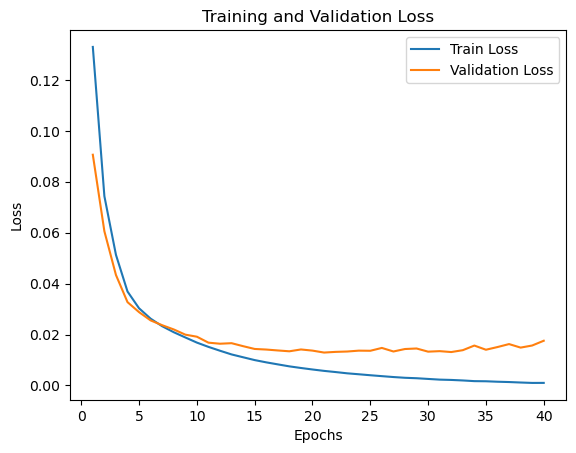

In [20]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.model_selection import train_test_split
from torchmetrics.classification import Precision, Recall, F1Score, MatthewsCorrCoef

kidera_encoded_sequences_tensor = torch.tensor(kidera_encoded_sequences, dtype=torch.float32)
labels_tensor = torch.tensor(bincode_encoded, dtype=torch.float32)  # labels are converted to float for BCE loss

# Permute the tensor to [num_sequences, num_features, sequence_length]
kidera_encoded_sequences_tensor = kidera_encoded_sequences_tensor.permute(0, 2, 1)


# Data split

# The code still splits the data randomly,
# the stratififed split will be implemented later

labels = labels_tensor.numpy()

# sum of labels across all samples for each class
label_sums = labels.sum(axis=0) # computes the sum of 1s along the rows

# Create indices and shuffle them
indices = np.arange(len(labels))
np.random.seed(42)
np.random.shuffle(indices)

# Split
split_point = int(0.8 * len(labels))  # 80-20 split
train_indices = indices[:split_point]
val_indices = indices[split_point:]

features_train, features_val = kidera_encoded_sequences_tensor[train_indices], kidera_encoded_sequences_tensor[val_indices]
labels_train, labels_val = labels_tensor[train_indices], labels_tensor[val_indices]

print("Class distribution in train set:", labels_train.sum(axis=0))
print("Class distribution in validation set:", labels_val.sum(axis=0))

#print("Average number of sequences in one bin in train set: ", labels_train.mean(axis=0))
#print("Average number of sequences in one bin in validation set: ", labels_val.mean(axis=0))

    
# Convert back to PyTorch tensors
features_train_tensor = torch.tensor(features_train, dtype=torch.float32)
features_val_tensor = torch.tensor(features_val, dtype=torch.float32)
labels_train_tensor = torch.tensor(labels_train, dtype=torch.float32)
labels_val_tensor = torch.tensor(labels_val, dtype=torch.float32)


# Create TensorDatasets
train_dataset = TensorDataset(features_train_tensor, labels_train_tensor)
val_dataset = TensorDataset(features_val_tensor, labels_val_tensor)

# DataLoaders for batching
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


print("labels_tensor shape:", labels_tensor.shape)
print("Unique values in labels_tensor:", torch.unique(labels_tensor))
print("Input shape:", kidera_encoded_sequences_tensor.shape)
print("Labels shape:", labels_tensor.shape)
print(f"Train set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

num_classes = labels_tensor.shape[1]

# CNN Model defined (uncomment to add dropout layers)

class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super(ConvolutionalNetwork, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=10, out_channels=32, kernel_size=7, stride=2)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        #self.dropout1 = nn.Dropout(p=0.2)  # Dropout after first pooling

        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=2)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        #self.dropout2 = nn.Dropout(p=0.2)  # Dropout after second pooling

        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=2)
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)
        #self.dropout3 = nn.Dropout(p=0.2)  # Dropout after third pooling

        self.conv4 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, stride=2)
        self.pool4 = nn.MaxPool1d(kernel_size=2, stride=2)
        #self.dropout4 = nn.Dropout(p=0.2)  # Dropout after fourth pooling

        self._calculate_conv_output_size()
        
        self.fc = nn.Linear(self.conv_output_size, num_classes)
        #self.fc_dropout = nn.Dropout(p=0.5)  # Dropout before fully connected layer
        self.sigmoid = nn.Sigmoid()  

    def _calculate_conv_output_size(self):
        dummy_input = torch.rand(1, 10, 4500)  
        dummy_output = self.conv1(dummy_input)
        dummy_output = self.pool1(dummy_output)
        dummy_output = self.conv2(dummy_output)
        dummy_output = self.pool2(dummy_output)
        dummy_output = self.conv3(dummy_output)
        dummy_output = self.pool3(dummy_output)
        dummy_output = self.conv4(dummy_output)
        dummy_output = self.pool4(dummy_output)
        self.conv_output_size = dummy_output.size(1) * dummy_output.size(2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.pool1(x)
        #x = self.dropout1(x)  
        x = self.conv2(x)
        x = self.pool2(x)
        #x = self.dropout2(x)  
        x = self.conv3(x)
        x = self.pool3(x)
        #x = self.dropout3(x) 
        x = self.conv4(x)
        x = self.pool4(x)
        #x = self.dropout4(x)  

        x = x.view(x.size(0), -1)  # Flatten
        #x = self.fc_dropout(x)  
        x = self.fc(x)
        x = self.sigmoid(x)
        return x


# Model, loss function, and optimizer initialisation
model = ConvolutionalNetwork()
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Training
epochs = 40
train_losses = []
val_losses = []


# Measure training time
start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)

start_event.record()  # Start timing

for epoch in range(epochs):
    model.train()
    total_train_loss = 0.0

    # Training loop
    for batch in train_loader:
        batch_data, batch_labels = batch
        optimizer.zero_grad()
        outputs = model(batch_data)
        loss = loss_fn(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    # Validation loop
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch_data, batch_labels = batch
            outputs = model(batch_data)
            loss = loss_fn(outputs, batch_labels)
            total_val_loss += loss.item()

    # Average losses
    train_loss = total_train_loss / len(train_loader)
    val_loss = total_val_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

end_event.record()  # End timing
torch.cuda.synchronize()  # Ensure CUDA operations are completed

# Calculate elapsed time
elapsed_time = start_event.elapsed_time(end_event) / 1000  # Convert to seconds
elapsed_time_minutes = elapsed_time / 60  # Convert seconds to minutes

#print(f"\nTotal training time: {elapsed_time:.2f} seconds")
print(f"Total training time: {elapsed_time_minutes:.2f} minutes")    
    
# Metric calculation after all epochs
print("\nCalculating metrics on the validation set...")

# Metrics initialization
precision_metric = Precision(task='multilabel', num_labels=num_classes, average='weighted')
recall_metric = Recall(task='multilabel', num_labels=num_classes, average='weighted')
f1_metric = F1Score(task='multilabel', num_labels=num_classes, average='weighted')
mcc_metric = MatthewsCorrCoef(task='multilabel', num_labels=num_classes)

y_test = []
y_pred = []

# Evaluate metrics on validation set
model.eval()
precision_metric.reset()
recall_metric.reset()
f1_metric.reset()
mcc_metric.reset()

with torch.no_grad():
    for batch in val_loader:
        batch_data, batch_labels = batch
        outputs = model(batch_data)
        predictions = (outputs > 0.5).int()  # Convert probabilities to binary and integer type
        batch_labels = batch_labels.int()   # Ensure labels are also integers
        y_test.extend(batch_labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

        
        # Update metrics with predictions and true labels
        precision_metric.update(predictions, batch_labels)
        recall_metric.update(predictions, batch_labels)
        f1_metric.update(predictions, batch_labels)
        mcc_metric.update(predictions, batch_labels)
        
y_test = np.array(y_test)
y_pred = np.array(y_pred)

print("Sample predictions:", y_pred[:10])

# shapes of the predictions and true labels
print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)

# Number of classes
print("Number of classes:", num_classes)

# Compute and display metrics
precision = precision_metric.compute()
recall = recall_metric.compute()
f1 = f1_metric.compute()
mcc = mcc_metric.compute()

y_pred_class = y_pred.argmax(axis=1)  # Select the highest-probability class
y_true_class = y_test.argmax(axis=1)
accuracy = (y_pred_class == y_true_class).mean()
print(f"Accuracy: {accuracy:.4f}")


print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

# Plot training and validation loss
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


### CNN Model with cross validation

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchmetrics import Precision, Recall, F1Score, MatthewsCorrCoef
from sklearn.model_selection import KFold
import numpy as np
import matplotlib.pyplot as plt

# Ensure reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Dataset Preparation
kidera_encoded_sequences_tensor = torch.tensor(kidera_encoded_sequences, dtype=torch.float32)
labels_tensor = torch.tensor(bincode_encoded, dtype=torch.float32)

# Permute to [num_sequences, num_features, sequence_length]
kidera_encoded_sequences_tensor = kidera_encoded_sequences_tensor.permute(0, 2, 1)

# Model Definition
class ConvolutionalNetwork(nn.Module):
    def __init__(self, num_classes):
        super(ConvolutionalNetwork, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=10, out_channels=32, kernel_size=7, stride=2)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=2)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=2)
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)
        self.conv4 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, stride=2)
        self.pool4 = nn.MaxPool1d(kernel_size=2, stride=2)
        self._calculate_conv_output_size()
        self.fc = nn.Linear(self.conv_output_size, num_classes)
        self.sigmoid = nn.Sigmoid()

    def _calculate_conv_output_size(self):
        dummy_input = torch.rand(1, 10, 4900)
        dummy_output = self.pool1(self.conv1(dummy_input))
        dummy_output = self.pool2(self.conv2(dummy_output))
        dummy_output = self.pool3(self.conv3(dummy_output))
        dummy_output = self.pool4(self.conv4(dummy_output))
        self.conv_output_size = dummy_output.size(1) * dummy_output.size(2)

    def forward(self, x):
        x = self.pool1(self.conv1(x))
        x = self.pool2(self.conv2(x))
        x = self.pool3(self.conv3(x))
        x = self.pool4(self.conv4(x))
        x = x.view(x.size(0), -1)
        x = self.sigmoid(self.fc(x))
        return x

# Cross-Validation Setup
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
batch_size = 64
epochs = 40
num_classes = labels_tensor.shape[1]

# Metrics Storage
fold_train_losses, fold_val_losses = [], []
fold_precisions, fold_recalls, fold_f1s, fold_mccs = [], [], [], []

# Cross-Validation Loop
for fold, (train_idx, val_idx) in enumerate(kf.split(kidera_encoded_sequences_tensor)):
    print(f"Fold {fold + 1}/{k_folds}")
    
    # Split data
    features_train, features_val = kidera_encoded_sequences_tensor[train_idx], kidera_encoded_sequences_tensor[val_idx]
    labels_train, labels_val = labels_tensor[train_idx], labels_tensor[val_idx]

    train_dataset = TensorDataset(features_train, labels_train)
    val_dataset = TensorDataset(features_val, labels_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Initialize model, loss, optimizer
    model = ConvolutionalNetwork(num_classes=num_classes)
    loss_fn = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

    # Training Loop
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        for batch in train_loader:
            batch_data, batch_labels = batch
            optimizer.zero_grad()
            outputs = model(batch_data)
            loss = loss_fn(outputs, batch_labels)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        # Validation
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                batch_data, batch_labels = batch
                outputs = model(batch_data)
                loss = loss_fn(outputs, batch_labels)
                total_val_loss += loss.item()

        train_losses.append(total_train_loss / len(train_loader))
        val_losses.append(total_val_loss / len(val_loader))

    # Final metrics for this fold
    model.eval()
    precision_metric = Precision(task='multilabel', num_labels=num_classes, average='weighted')
    recall_metric = Recall(task='multilabel', num_labels=num_classes, average='weighted')
    f1_metric = F1Score(task='multilabel', num_labels=num_classes, average='weighted')
    mcc_metric = MatthewsCorrCoef(task='multilabel', num_labels=num_classes)

    with torch.no_grad():
        for batch in val_loader:
            batch_data, batch_labels = batch
            outputs = model(batch_data)
            predictions = (outputs > 0.5).int()
            precision_metric.update(predictions, batch_labels.int())
            recall_metric.update(predictions, batch_labels.int())
            f1_metric.update(predictions, batch_labels.int())
            mcc_metric.update(predictions, batch_labels.int())

    precision = precision_metric.compute()
    recall = recall_metric.compute()
    f1 = f1_metric.compute()
    mcc = mcc_metric.compute()

    # Store metrics
    fold_train_losses.append(train_losses[-1])
    fold_val_losses.append(val_losses[-1])
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1s.append(f1)
    fold_mccs.append(mcc)

    print(f"Fold {fold + 1} - Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, MCC: {mcc:.4f}")

# Final Aggregated Results
print("\nCross-Validation Results:")
print(f"Average Train Loss: {np.mean(fold_train_losses):.4f}")
print(f"Average Val Loss: {np.mean(fold_val_losses):.4f}")
print(f"Average Precision: {np.mean(fold_precisions):.4f}")
print(f"Average Recall: {np.mean(fold_recalls):.4f}")
print(f"Average F1 Score: {np.mean(fold_f1s):.4f}")
print(f"Average MCC: {np.mean(fold_mccs):.4f}")

### CNN Model with average pooling

Class distribution in train set: tensor([ 502., 1212.,  796.,  646.,  356., 4783.,  403.,  645.,  312., 2096.,
        3216.,  208.,  761., 1982.,  813.,  300., 2985.,  507., 2437., 1391.,
         427.,  432.,  536.,  127.,  293.,  860.,  348.,  380., 1187., 1300.])
Class distribution in validation set: tensor([ 119.,  318.,  188.,  168.,   71., 1193.,  127.,  185.,   69.,  523.,
         794.,   47.,  212.,  498.,  217.,   91.,  761.,  137.,  599.,  320.,
          95.,  108.,  133.,   29.,   65.,  214.,   79.,   85.,  311.,  305.])


/tmp/ipykernel_33857/2604597493.py:48: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features_train_tensor = torch.tensor(features_train, dtype=torch.float32)
/tmp/ipykernel_33857/2604597493.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features_val_tensor = torch.tensor(features_val, dtype=torch.float32)
/tmp/ipykernel_33857/2604597493.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_train_tensor = torch.tensor(labels_train, dtype=torch.float32)
/tmp/ipykernel_33857/2604597493.py:51: UserWarning: To copy construct from 

labels_tensor shape: torch.Size([40302, 30])
Unique values in labels_tensor: tensor([0., 1.])
Input shape: torch.Size([40302, 10, 3500])
Labels shape: torch.Size([40302, 30])
Train set size: 32241
Validation set size: 8061
Epoch 1/40 - Train Loss: 0.1487, Val Loss: 0.0972
Epoch 2/40 - Train Loss: 0.0832, Val Loss: 0.0729
Epoch 3/40 - Train Loss: 0.0654, Val Loss: 0.0571
Epoch 4/40 - Train Loss: 0.0498, Val Loss: 0.0455
Epoch 5/40 - Train Loss: 0.0414, Val Loss: 0.0372
Epoch 6/40 - Train Loss: 0.0344, Val Loss: 0.0329
Epoch 7/40 - Train Loss: 0.0303, Val Loss: 0.0296
Epoch 8/40 - Train Loss: 0.0280, Val Loss: 0.0279
Epoch 9/40 - Train Loss: 0.0265, Val Loss: 0.0274
Epoch 10/40 - Train Loss: 0.0255, Val Loss: 0.0260
Epoch 11/40 - Train Loss: 0.0247, Val Loss: 0.0260
Epoch 12/40 - Train Loss: 0.0240, Val Loss: 0.0248
Epoch 13/40 - Train Loss: 0.0233, Val Loss: 0.0243
Epoch 14/40 - Train Loss: 0.0226, Val Loss: 0.0236
Epoch 15/40 - Train Loss: 0.0218, Val Loss: 0.0228
Epoch 16/40 - Train L

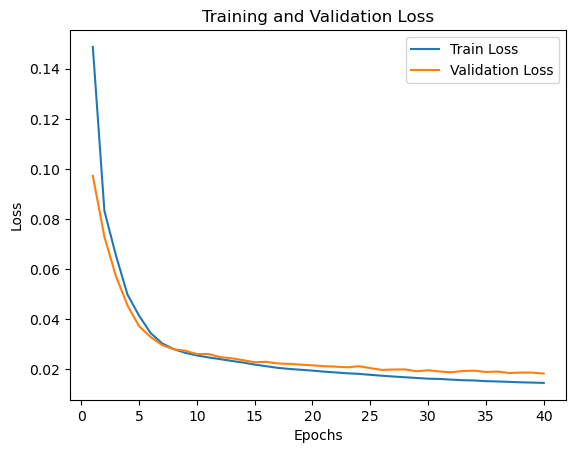

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.model_selection import train_test_split
from torchmetrics.classification import Precision, Recall, F1Score, MatthewsCorrCoef

kidera_encoded_sequences_tensor = torch.tensor(kidera_encoded_sequences, dtype=torch.float32)
labels_tensor = torch.tensor(bincode_encoded, dtype=torch.float32)  # labels are converted to float for BCE loss

# Permute the tensor to [num_sequences, num_features, sequence_length]
kidera_encoded_sequences_tensor = kidera_encoded_sequences_tensor.permute(0, 2, 1)


# Data split

# The code still splits the data randomly,
# the stratififed split will be implemented later

labels = labels_tensor.numpy()

# sum of labels across all samples for each class
label_sums = labels.sum(axis=0) # computes the sum of 1s along the rows

# Create indices and shuffle them
indices = np.arange(len(labels))
np.random.seed(42)
np.random.shuffle(indices)

# Split
split_point = int(0.8 * len(labels))  # 80-20 split
train_indices = indices[:split_point]
val_indices = indices[split_point:]

features_train, features_val = kidera_encoded_sequences_tensor[train_indices], kidera_encoded_sequences_tensor[val_indices]
labels_train, labels_val = labels_tensor[train_indices], labels_tensor[val_indices]

print("Class distribution in train set:", labels_train.sum(axis=0))
print("Class distribution in validation set:", labels_val.sum(axis=0))

#print("Average number of sequences in one bin in train set: ", labels_train.mean(axis=0))
#print("Average number of sequences in one bin in validation set: ", labels_val.mean(axis=0))

    
# Convert back to PyTorch tensors
features_train_tensor = torch.tensor(features_train, dtype=torch.float32)
features_val_tensor = torch.tensor(features_val, dtype=torch.float32)
labels_train_tensor = torch.tensor(labels_train, dtype=torch.float32)
labels_val_tensor = torch.tensor(labels_val, dtype=torch.float32)


# Create TensorDatasets
train_dataset = TensorDataset(features_train_tensor, labels_train_tensor)
val_dataset = TensorDataset(features_val_tensor, labels_val_tensor)

# DataLoaders for batching
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


print("labels_tensor shape:", labels_tensor.shape)
print("Unique values in labels_tensor:", torch.unique(labels_tensor))
print("Input shape:", kidera_encoded_sequences_tensor.shape)
print("Labels shape:", labels_tensor.shape)
print(f"Train set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

num_classes = labels_tensor.shape[1]

# CNN Model defined (uncomment to add dropout layers)

class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super(ConvolutionalNetwork, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=10, out_channels=32, kernel_size=7, stride=2)
        self.avgpool1 = nn.AvgPool1d(kernel_size=2, stride=2) # average pooling
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=2)
        self.avgpool2 = nn.AvgPool1d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=2)
        self.avgpool3 = nn.AvgPool1d(kernel_size=2, stride=2)
        self.conv4 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, stride=2)
        self.avgpool4 = nn.AvgPool1d(kernel_size=2, stride=2)
        self._calculate_conv_output_size()
        self.fc = nn.Linear(self.conv_output_size, num_classes)
        self.sigmoid = nn.Sigmoid()

    def _calculate_conv_output_size(self):
        dummy_input = torch.rand(1, 10, 3500)
        dummy_output = self.avgpool1(self.conv1(dummy_input))
        dummy_output = self.avgpool2(self.conv2(dummy_output))
        dummy_output = self.avgpool3(self.conv3(dummy_output))
        dummy_output = self.avgpool4(self.conv4(dummy_output))
        self.conv_output_size = dummy_output.size(1) * dummy_output.size(2)

    def forward(self, x):
        x = self.avgpool1(self.conv1(x))
        x = self.avgpool2(self.conv2(x))
        x = self.avgpool3(self.conv3(x))
        x = self.avgpool4(self.conv4(x))
        x = x.view(x.size(0), -1)
        x = self.sigmoid(self.fc(x))
        return x

# Model, loss function, and optimizer initialisation
model = ConvolutionalNetwork()
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Training
epochs = 40
train_losses = []
val_losses = []

# Measure training time
start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)

start_event.record()  # Start timing

for epoch in range(epochs):
    model.train()
    total_train_loss = 0.0

    # Training loop
    for batch in train_loader:
        batch_data, batch_labels = batch
        optimizer.zero_grad()
        outputs = model(batch_data)
        loss = loss_fn(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    # Validation loop
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch_data, batch_labels = batch
            outputs = model(batch_data)
            loss = loss_fn(outputs, batch_labels)
            total_val_loss += loss.item()

    # Average losses
    train_loss = total_train_loss / len(train_loader)
    val_loss = total_val_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

end_event.record()  # End timing
torch.cuda.synchronize()  # Ensure CUDA operations are completed

# Calculate elapsed time
elapsed_time = start_event.elapsed_time(end_event) / 1000  # Convert to seconds
elapsed_time_minutes = elapsed_time / 60  # Convert seconds to minutes

#print(f"\nTotal training time: {elapsed_time:.2f} seconds")
print(f"Total training time: {elapsed_time_minutes:.2f} minutes")


# Metric calculation after all epochs
print("\nCalculating metrics on the validation set...")

# Metrics initialization
precision_metric = Precision(task='multilabel', num_labels=num_classes, average='weighted')
recall_metric = Recall(task='multilabel', num_labels=num_classes, average='weighted')
f1_metric = F1Score(task='multilabel', num_labels=num_classes, average='weighted')
mcc_metric = MatthewsCorrCoef(task='multilabel', num_labels=num_classes)

y_test = []
y_pred = []

# Evaluate metrics on validation set
model.eval()
precision_metric.reset()
recall_metric.reset()
f1_metric.reset()
mcc_metric.reset()

with torch.no_grad():
    for batch in val_loader:
        batch_data, batch_labels = batch
        outputs = model(batch_data)
        predictions = (outputs > 0.5).int()  # Convert probabilities to binary and integer type
        batch_labels = batch_labels.int()   # Ensure labels are also integers
        y_test.extend(batch_labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

        
        # Update metrics with predictions and true labels
        precision_metric.update(predictions, batch_labels)
        recall_metric.update(predictions, batch_labels)
        f1_metric.update(predictions, batch_labels)
        mcc_metric.update(predictions, batch_labels)
        
y_test = np.array(y_test)
y_pred = np.array(y_pred)

print("Sample predictions:", y_pred[:10])

# shapes of the predictions and true labels
print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)

# Number of classes
print("Number of classes:", num_classes)

# Compute and display metrics
precision = precision_metric.compute()
recall = recall_metric.compute()
f1 = f1_metric.compute()
mcc = mcc_metric.compute()

y_pred_class = y_pred.argmax(axis=1)  # Select the highest-probability class
y_true_class = y_test.argmax(axis=1)
accuracy = (y_pred_class == y_true_class).mean()
print(f"Accuracy: {accuracy:.4f}")


print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

# Plot training and validation loss
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


### CNN Model with AveragePooling and cross validation (Not tested yet due to long training time)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchmetrics import Precision, Recall, F1Score, MatthewsCorrCoef
from sklearn.model_selection import KFold
import numpy as np
import matplotlib.pyplot as plt

# Ensure reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Dataset Preparation
kidera_encoded_sequences_tensor = torch.tensor(kidera_encoded_sequences, dtype=torch.float32)
labels_tensor = torch.tensor(bincode_encoded, dtype=torch.float32)

# Permute to [num_sequences, num_features, sequence_length]
kidera_encoded_sequences_tensor = kidera_encoded_sequences_tensor.permute(0, 2, 1)

# Model Definition
class ConvolutionalNetwork(nn.Module):
    def __init__(self, num_classes):
        super(ConvolutionalNetwork, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=10, out_channels=32, kernel_size=7, stride=2)
        self.avgpool1 = nn.AvgPool1d(kernel_size=2, stride=2) # average pooling
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=2)
        self.avgpool2 = nn.AvgPool1d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=2)
        self.avgpool3 = nn.AvgPool1d(kernel_size=2, stride=2)
        self.conv4 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, stride=2)
        self.avgpool4 = nn.AvgPool1d(kernel_size=2, stride=2)
        self._calculate_conv_output_size()
        self.fc = nn.Linear(self.conv_output_size, num_classes)
        self.sigmoid = nn.Sigmoid()

    def _calculate_conv_output_size(self):
        dummy_input = torch.rand(1, 10, 1500)
        dummy_output = self.avgpool1(self.conv1(dummy_input))
        dummy_output = self.avgpool2(self.conv2(dummy_output))
        dummy_output = self.avgpool3(self.conv3(dummy_output))
        dummy_output = self.avgpool4(self.conv4(dummy_output))
        self.conv_output_size = dummy_output.size(1) * dummy_output.size(2)

    def forward(self, x):
        x = self.avgpool1(self.conv1(x))
        x = self.avgpool2(self.conv2(x))
        x = self.avgpool3(self.conv3(x))
        x = self.avgpool4(self.conv4(x))
        x = x.view(x.size(0), -1)
        x = self.sigmoid(self.fc(x))
        return x

# Cross-Validation Setup
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
batch_size = 64
epochs = 40
num_classes = labels_tensor.shape[1]

# Metrics Storage
fold_train_losses, fold_val_losses = [], []
fold_precisions, fold_recalls, fold_f1s, fold_mccs = [], [], [], []

# Cross-Validation Loop
for fold, (train_idx, val_idx) in enumerate(kf.split(kidera_encoded_sequences_tensor)):
    print(f"Fold {fold + 1}/{k_folds}")
    
    # Split data
    features_train, features_val = kidera_encoded_sequences_tensor[train_idx], kidera_encoded_sequences_tensor[val_idx]
    labels_train, labels_val = labels_tensor[train_idx], labels_tensor[val_idx]

    train_dataset = TensorDataset(features_train, labels_train)
    val_dataset = TensorDataset(features_val, labels_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Initialize model, loss, optimizer
    model = ConvolutionalNetwork(num_classes=num_classes)
    loss_fn = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

    # Training Loop
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        for batch in train_loader:
            batch_data, batch_labels = batch
            optimizer.zero_grad()
            outputs = model(batch_data)
            loss = loss_fn(outputs, batch_labels)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        # Validation
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                batch_data, batch_labels = batch
                outputs = model(batch_data)
                loss = loss_fn(outputs, batch_labels)
                total_val_loss += loss.item()

        train_losses.append(total_train_loss / len(train_loader))
        val_losses.append(total_val_loss / len(val_loader))

    # Final metrics for this fold
    model.eval()
    precision_metric = Precision(task='multilabel', num_labels=num_classes, average='weighted')
    recall_metric = Recall(task='multilabel', num_labels=num_classes, average='weighted')
    f1_metric = F1Score(task='multilabel', num_labels=num_classes, average='weighted')
    mcc_metric = MatthewsCorrCoef(task='multilabel', num_labels=num_classes)

    with torch.no_grad():
        for batch in val_loader:
            batch_data, batch_labels = batch
            outputs = model(batch_data)
            predictions = (outputs > 0.5).int()
            precision_metric.update(predictions, batch_labels.int())
            recall_metric.update(predictions, batch_labels.int())
            f1_metric.update(predictions, batch_labels.int())
            mcc_metric.update(predictions, batch_labels.int())

    precision = precision_metric.compute()
    recall = recall_metric.compute()
    f1 = f1_metric.compute()
    mcc = mcc_metric.compute()

    # Store metrics
    fold_train_losses.append(train_losses[-1])
    fold_val_losses.append(val_losses[-1])
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1s.append(f1)
    fold_mccs.append(mcc)

    print(f"Fold {fold + 1} - Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, MCC: {mcc:.4f}")

# Final Aggregated Results
print("\nCross-Validation Results:")
print(f"Average Train Loss: {np.mean(fold_train_losses):.4f}")
print(f"Average Val Loss: {np.mean(fold_val_losses):.4f}")
print(f"Average Precision: {np.mean(fold_precisions):.4f}")
print(f"Average Recall: {np.mean(fold_recalls):.4f}")
print(f"Average F1 Score: {np.mean(fold_f1s):.4f}")
print(f"Average MCC: {np.mean(fold_mccs):.4f}")

Fold 1/5
Fold 1 - Train Loss: 0.0147, Val Loss: 0.0178
Precision: 0.9500, Recall: 0.9053, F1: 0.9265, MCC: 0.9254
Fold 2/5
Fold 2 - Train Loss: 0.0143, Val Loss: 0.0173
Precision: 0.9499, Recall: 0.9106, F1: 0.9291, MCC: 0.9279
Fold 3/5
Fold 3 - Train Loss: 0.0148, Val Loss: 0.0183
Precision: 0.9534, Recall: 0.9073, F1: 0.9288, MCC: 0.9274
Fold 4/5
Fold 4 - Train Loss: 0.0147, Val Loss: 0.0183
Precision: 0.9558, Recall: 0.9019, F1: 0.9271, MCC: 0.9259
Fold 5/5


## Experiment history

26.01.2025 changes:

- Embedding using 188 Kidera factors
- Two empty factors were removed -> 186 kidera factors

- First embedding, then padding, length = 1500
- Result: kernel died during embedding step

-  First embedding, then padding, length = 900
- Result: kernel died during embedding step

- First padding, then embedding, length = 900
- Result: kernel died during embedding step
--> Idea of embedding with 186 kidera factors is abandoned

- Average pooling after each convolutional layer (kernel_size=2, stride=2), 40 epochs
-> Result: Precision: 0.9402; Recall: 0.8720; F1 Score: 0.9032; MCC: 0.9039

- Average pooling + cross validation implemented, but not tested yet



27.01.2025 changes

- Average pooling; 1500 aa
- Result: Precision: 0.9591; Recall: 0.9008; F1 Score: 0.9280; MCC: 0.9276; time: 17.20 minutes

- avg pooling; 3500
- Result:  Presicion: 0.9477; Recall: 0.9098; F1 score: 0.9273; MCC: 0.9263; time: 30.27 minutes

- 1500; 40 epochs, adam, max Pooling, Learning rate=0.0001 (time measurement)
- Result: time: 15.77 minutes

- 2500; 40 epochs, SGD, max Pooling, weight decay = 1e-4, Learning rate=0.1 (time measurement)
- Result: time: 29.56 minutes

- 4500; 40 epochs, adam, max Pooling, Learning rate=0.0001 (time measurement)
- Result: 41.51 minutes